**Assignment 1. Digital Signal Processing**



1st part

In [1]:
from typing import Optional

import torch
from torch import nn
from torchaudio import functional as F

In [2]:
class LogMelFilterBanks(nn.Module):
    def __init__(
            self,
            n_fft: int = 400,
            samplerate: int = 16000,
            hop_length: int = 160,
            n_mels: int = 80,
            pad_mode: str = 'reflect',
            power: float = 2.0,
            normalize_stft: bool = False,
            onesided: bool = True,
            center: bool = True,
            return_complex: bool = True,
            f_min_hz: float = 0.0,
            f_max_hz: Optional[float] = None,
            norm_mel: Optional[str] = None,
            mel_scale: str = 'htk'
        ):
        super(LogMelFilterBanks, self).__init__()
        # general params and params defined by the exercise
        self.n_fft = n_fft
        self.samplerate = samplerate
        self.window_length = n_fft
        self.window = torch.hann_window(self.window_length)
        # Do correct initialization of stft params below:
        # hop_length, n_mels, center, return_complex, onesided, normalize_stft, pad_mode, power
        # ...

        # Инициализируем параметры stft
        self.hop_length = hop_length
        self.n_mels = n_mels
        self.center = center
        self.return_complex = return_complex
        self.onesided = onesided
        self.normalize_stft = normalize_stft
        self.pad_mode = pad_mode
        self.power = power

        # Do correct initialization of mel fbanks params below:
        # f_min_hz, f_max_hz, norm_mel, mel_scale
        # ...

        # Инициализируем параметры мел-фильтров
        self.f_min_hz = f_min_hz
        # Если максимальная частота не задана, используем частоту Найквиста
        self.f_max_hz = f_max_hz if f_max_hz is not None else float(samplerate) / 2
        self.norm_mel = norm_mel
        self.mel_scale = mel_scale

        # finish parameters initialization
        self.mel_fbanks = self._init_melscale_fbanks()

    def _init_melscale_fbanks(self):
        # To access attributes, use self.<parameter_name>
            # Turns a normal STFT into a mel frequency STFT with triangular filter banks
            # make a full and correct function call

        # Количество частотных бинов зависит от параметра onesided
        n_freqs = self.n_fft // 2 + 1 if self.onesided else self.n_fft

        return F.melscale_fbanks(
            n_freqs=n_freqs,
            f_min=self.f_min_hz,
            f_max=self.f_max_hz,
            n_mels=self.n_mels,
            sample_rate=self.samplerate,
            norm=self.norm_mel,
            mel_scale=self.mel_scale
        )

    def spectrogram(self, x):
        # x - is an input signal
        return torch.stft(
            # make a full and correct function call
            x,
            n_fft=self.n_fft,
            hop_length=self.hop_length,
            win_length=self.window_length,
            window=self.window.to(x.device),  # Переносим окно на то же устройство, что и входные данные
            center=self.center,
            pad_mode=self.pad_mode,
            normalized=self.normalize_stft,
            onesided=self.onesided,
            return_complex=self.return_complex
        )

    def forward(self, x):
        """
        Args:
            x (Torch.Tensor): Tensor of audio of dimension (batch, time), audiosignal
        Returns:
            Torch.Tensor: Tensor of log mel filterbanks of dimension (batch, n_mels, n_frames),
                where n_frames is a function of the window_length, hop_length and length of audio
        """
        # Return log mel filterbanks matrix

        # Вычисляем stft
        stft_output = self.spectrogram(x)

        # Вычисляем спектрограмму мощности
        if self.return_complex:
            # Если stft возвращает комплексный тензор
            power_spec = torch.abs(stft_output) ** self.power
        else:
            # Если stft возвращает действительную и мнимую части отдельно
            power_spec = (stft_output[..., 0] ** 2 + stft_output[..., 1] ** 2) ** (self.power / 2)

        # Переносим мел-фильтры на то же устройство
        mel_fbanks = self.mel_fbanks.to(x.device)

        # Применяем мел-фильтры
        mel_spec = torch.matmul(power_spec.transpose(1, 2), mel_fbanks)
        mel_spec = mel_spec.transpose(1, 2)  # (batch, n_mels, n_frames)

        log_mel_spec = torch.log(mel_spec + 1e-6)

        return log_mel_spec

In [46]:
# Протестим, создав для этого тестовое аудио
import torch
import torchaudio
import numpy as np

# Создаем тон 440 Гц длительностью 2 секунды
sr = 16000
duration = 2.0
t = torch.linspace(0, duration, int(sr * duration))
signal = 0.5 * torch.sin(2 * np.pi * 440 * t)  # нота Ля
signal = signal.unsqueeze(0)  # добавляем размерность канала

torchaudio.save('test_audio.wav', signal, sr)

Все проверки пройдены!


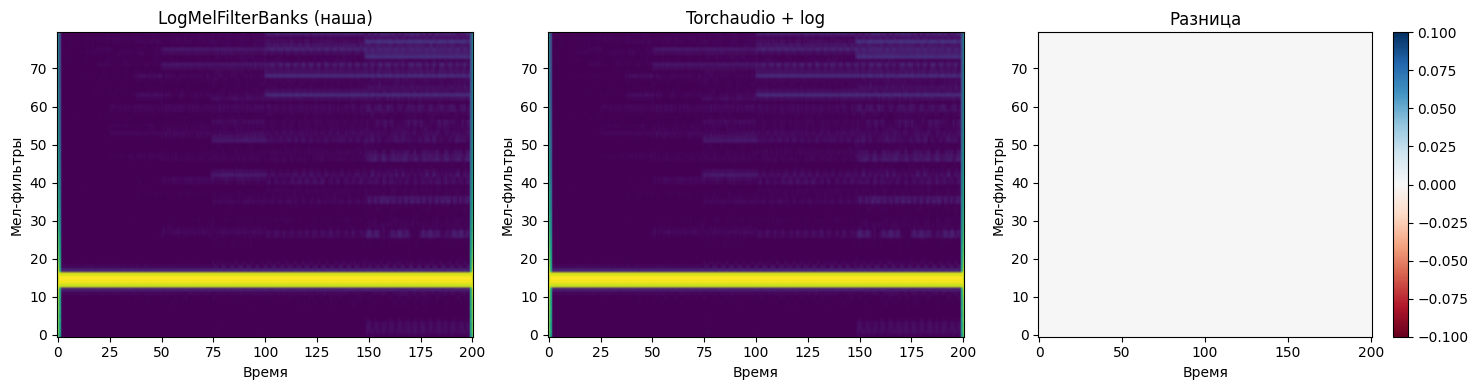

График сохранен: comparison_plot.png


In [51]:
import torch
import torchaudio
import matplotlib.pyplot as plt

# Загружаем аудио
signal, sr = torchaudio.load('test_audio.wav')

# Torchaudio реализация
melspec = torchaudio.transforms.MelSpectrogram(hop_length=160, n_mels=80)(signal)
torch_log = torch.log(melspec + 1e-6)

# Моя реализация
our_log = LogMelFilterBanks()(signal)

# Проверки из задания

melspec = torchaudio.transforms.MelSpectrogram(
    hop_length=160,
    n_mels=80
)(signal)
logmelbanks = LogMelFilterBanks()(signal)

assert torch.log(melspec + 1e-6).shape == logmelbanks.shape
assert torch.allclose(torch.log(melspec + 1e-6), logmelbanks)
print("Все проверки пройдены!")

# График для отчета
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))

ax1.imshow(our_log[0].cpu().numpy(), aspect='auto', origin='lower', cmap='viridis')
ax1.set_title('LogMelFilterBanks (наша)')
ax1.set_xlabel('Время')
ax1.set_ylabel('Мел-фильтры')

ax2.imshow(torch_log[0].cpu().numpy(), aspect='auto', origin='lower', cmap='viridis')
ax2.set_title('Torchaudio + log')
ax2.set_xlabel('Время')
ax2.set_ylabel('Мел-фильтры')

diff = (our_log[0] - torch_log[0]).cpu().numpy()
im = ax3.imshow(diff, aspect='auto', origin='lower', cmap='RdBu', vmin=-0.1, vmax=0.1)
ax3.set_title('Разница')
ax3.set_xlabel('Время')
ax3.set_ylabel('Мел-фильтры')
plt.colorbar(im, ax=ax3)

plt.tight_layout()
plt.savefig('comparison_plot.png', dpi=150)
plt.show()
print("График сохранен: comparison_plot.png")

2nd part

In [6]:
import torch
from torch.utils.data import Dataset
from torchaudio.datasets import SPEECHCOMMANDS
import os

In [30]:
class BinarySpeechCommandsDataset(Dataset):

    def __init__(self, subset='training', max_length=16000):
        self.max_length = max_length
        os.makedirs('./data', exist_ok=True)

        # Загружаем датасет
        self.dataset = SPEECHCOMMANDS(root='./data', download=True, subset=subset)
        print(f"{subset}: датасет загружен, всего {len(self.dataset)} файлов")

        self.target_classes = ['yes', 'no']
        self.class_to_idx = {'yes': 0, 'no': 1}

        # Фильтруем только yes/no
        self.indices = []
        self.lengths = []
        for i in range(len(self.dataset)):
            try:
                waveform, sample_rate, label, *_ = self.dataset[i]
                if label in self.target_classes:
                    self.indices.append(i)
                    self.lengths.append(waveform.shape[1])
            except Exception as e:
                continue

        print(f"   Найдено {len(self.indices)} записей YES/NO")
        if len(self.lengths) > 0:
            print(f"   Длины: мин={min(self.lengths)}, макс={max(self.lengths)}, сред={np.mean(self.lengths):.0f}")

    # Выравниваем waveform до нужной длины
    def _pad_waveform(self, waveform):
        current_length = waveform.shape[0]
        if current_length < self.max_length:
            # Дополняем нулями справа
            padding = torch.zeros(self.max_length - current_length)
            waveform = torch.cat([waveform, padding])
        elif current_length > self.max_length:
            # Обрезаем
            waveform = waveform[:self.max_length]
        return waveform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        actual_idx = self.indices[idx]
        waveform, sample_rate, label, *_ = self.dataset[actual_idx]

        # Убираем размерность канала и выравниваем
        waveform = waveform.squeeze(0)
        waveform = self._pad_waveform(waveform)

        target = self.class_to_idx[label]
        return waveform, target

In [31]:
# Проверка

train_dataset = BinarySpeechCommandsDataset('training')
val_dataset = BinarySpeechCommandsDataset('validation')
test_dataset = BinarySpeechCommandsDataset('testing')

print(f"Размер тренировочного датасета: {len(train_dataset)}")
print(f"Размер валидационного датасета: {len(val_dataset)}")
print(f"Размер тестового датасета: {len(test_dataset)}")

# Проверяем один пример
waveform, label = train_dataset[0]
print(f"Форма аудио: {waveform.shape}")
print(f"Лейбл: {label} (0=YES, 1=NO)")

training: датасет загружен, всего 84843 файлов
   Найдено 6358 записей YES/NO
   Длины: мин=6144, макс=16000, сред=15709
validation: датасет загружен, всего 9981 файлов
   Найдено 803 записей YES/NO
   Длины: мин=6826, макс=16000, сред=15581
testing: датасет загружен, всего 11005 файлов
   Найдено 824 записей YES/NO
   Длины: мин=6826, макс=16000, сред=15830
Размер тренировочного датасета: 6358
Размер валидационного датасета: 803
Размер тестового датасета: 824
Форма аудио: torch.Size([16000])
Лейбл: 1 (0=YES, 1=NO)


In [32]:
# CNN

class SimpleCNN(nn.Module):
    def __init__(self, n_mels=80, groups=1):
        super().__init__()

        self.melbanks = LogMelFilterBanks(n_mels=n_mels)

        # Cлои
        self.conv1 = nn.Conv1d(n_mels, 32, kernel_size=3, padding=1, groups=groups)
        self.bn1 = nn.BatchNorm1d(32)

        self.conv2 = nn.Conv1d(32, 64, kernel_size=3, padding=1, groups=groups)
        self.bn2 = nn.BatchNorm1d(64)

        self.conv3 = nn.Conv1d(64, 128, kernel_size=3, padding=1, groups=groups)
        self.bn3 = nn.BatchNorm1d(128)

        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(128, 2)
        self.dropout = nn.Dropout(0.3)
        self.relu = nn.ReLU()

        # Считаем параметры
        total_params = sum(p.numel() for p in self.parameters())
        print(f"Модель создана: {total_params:,} параметров")
        assert total_params < 100000, f"Слишком много параметров: {total_params}"

    def forward(self, x):
        x = self.melbanks(x)
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.dropout(x)
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.dropout(x)
        x = self.relu(self.bn3(self.conv3(x)))
        x = self.global_pool(x).squeeze(-1)
        x = self.fc(x)
        return x

In [33]:
# Проверка устройства

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Наше устройство: {device}")

Наше устройство: cpu


In [40]:
# Функции для обучения

def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0

    for waveforms, labels in loader:
        waveforms, labels = waveforms.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(waveforms)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

def validate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for waveforms, labels in loader:
            waveforms, labels = waveforms.to(device), labels.to(device)
            outputs = model(waveforms)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return total_loss / len(loader), correct / total

# Подсчет FLOPs и параметров
# def count_flops_params(model, input_shape=(1, 16000)):
#     dummy_input = torch.randn(input_shape).to(device)
#     flops, params = profile(model, inputs=(dummy_input,), verbose=False)
#     return flops, params

def count_flops_params(model, input_shape=(1, 16000)):
    dummy_input = torch.randn(input_shape).to(device)

    # profile возвращает FLOPs (количество операций)
    flops, params = profile(model, inputs=(dummy_input,), verbose=False)

    # Форматируем для читаемости
    if flops > 1e9:
        flops_g = flops / 1e9
        print(f"FLOPs: {flops_g:.3f} G")
    elif flops > 1e6:
        flops_m = flops / 1e6
        print(f"FLOPs: {flops_m:.3f} M")
    else:
        flops_k = flops / 1e3
        print(f"FLOPs: {flops_k:.3f} K")

    return flops, params

In [20]:
!pip install thop -q

In [41]:
import matplotlib.pyplot as plt
import numpy as np
import time
from thop import profile, clever_format
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

def run_experiment(n_mels=80, groups=1, num_epochs=5):
    print(f"\n{'='*50}")
    print(f"Эксперимент: n_mels={n_mels}, groups={groups}")
    print(f"{'='*50}")

    # Создаем модель
    model = SimpleCNN(n_mels=n_mels, groups=groups).to(device)

    # Считаем FLOPs
    flops, params = count_flops_params(model)

    # Загружаем данные
    train_dataset = BinarySpeechCommandsDataset('training')
    val_dataset = BinarySpeechCommandsDataset('validation')

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, drop_last=True)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, drop_last=True)

    # Обучение
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_losses = []
    val_accs = []
    epoch_times = []

    for epoch in range(num_epochs):
        start_time = time.time()

        train_loss = train_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = validate(model, val_loader, criterion)

        epoch_time = time.time() - start_time

        train_losses.append(train_loss)
        val_accs.append(val_acc)
        epoch_times.append(epoch_time)

        print(f"Эпоха {epoch+1}: loss={train_loss:.4f}, val_acc={val_acc:.4f}, время={epoch_time:.2f}с")

    return {
        'n_mels': n_mels,
        'groups': groups,
        'train_losses': train_losses,
        'val_accs': val_accs,
        'epoch_times': epoch_times,
        'flops': flops,
        'params': params,
        'final_val_acc': val_accs[-1]
    }


# Запуск всех экспериментов
def run_all_experiments():
    results = {}

    # Эксперимент 1: разные n_mels
    print("Эксперимент 1: Разные n_mels")

    for n_mels in [20, 40, 80]:
        results[f'n_mels_{n_mels}'] = run_experiment(n_mels=n_mels, groups=1, num_epochs=5)

    # Эксперимент 2: разные groups
    print("Эксперимент 2: Разные groups")


    for groups in [1, 2, 4, 8, 16]:
        results[f'groups_{groups}'] = run_experiment(n_mels=80, groups=groups, num_epochs=5)

    return results

def plot_results(results):
    """Построение графиков результатов"""

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # График 1: n_mels vs accuracy
    n_mels_vals = [20, 40, 80]
    n_mels_accs = [results[f'n_mels_{n}']['final_val_acc'] for n in n_mels_vals]

    axes[0, 0].plot(n_mels_vals, n_mels_accs, 'bo-', linewidth=2, markersize=8)
    axes[0, 0].set_xlabel('n_mels')
    axes[0, 0].set_ylabel('Точность')
    axes[0, 0].set_title('Точность vs n_mels')
    axes[0, 0].grid(True)

    # График 2: n_mels vs параметры
    n_mels_params = [results[f'n_mels_{n}']['params']/1000 for n in n_mels_vals]
    axes[0, 1].bar(range(len(n_mels_vals)), n_mels_params, tick_label=n_mels_vals)
    axes[0, 1].set_xlabel('n_mels')
    axes[0, 1].set_ylabel('Параметры (тысячи)')
    axes[0, 1].set_title('Размер модели vs n_mels')

    # График 3: Кривые обучения для n_mels
    for n_mels in n_mels_vals:
        axes[0, 2].plot(results[f'n_mels_{n_mels}']['val_accs'],
                       label=f'n_mels={n_mels}')
    axes[0, 2].set_xlabel('Эпоха')
    axes[0, 2].set_ylabel('Точность')
    axes[0, 2].set_title('Кривые обучения')
    axes[0, 2].legend()
    axes[0, 2].grid(True)

    # График 4: groups vs accuracy
    groups_vals = [1, 2, 4, 8, 16]
    groups_accs = [results[f'groups_{g}']['final_val_acc'] for g in groups_vals]

    axes[1, 0].semilogx(groups_vals, groups_accs, 'ro-', linewidth=2, markersize=8, base=2)
    axes[1, 0].set_xlabel('groups')
    axes[1, 0].set_ylabel('Точность')
    axes[1, 0].set_title('Точность vs groups')
    axes[1, 0].grid(True)

    # График 5: groups vs параметры
    groups_params = [results[f'groups_{g}']['params']/1000 for g in groups_vals]
    axes[1, 1].semilogx(groups_vals, groups_params, 'go-', linewidth=2, markersize=8, base=2)
    axes[1, 1].set_xlabel('groups')
    axes[1, 1].set_ylabel('Параметры (тысячи)')
    axes[1, 1].set_title('Размер модели vs groups')
    axes[1, 1].grid(True)

    # График 6: groups vs время
    groups_times = [np.mean(results[f'groups_{g}']['epoch_times']) for g in groups_vals]
    axes[1, 2].semilogx(groups_vals, groups_times, 'mo-', linewidth=2, markersize=8, base=2)
    axes[1, 2].set_xlabel('groups')
    axes[1, 2].set_ylabel('Время эпохи (с)')
    axes[1, 2].set_title('Время обучения vs groups')
    axes[1, 2].grid(True)

    plt.suptitle('Результаты экспериментов', fontsize=16)
    plt.tight_layout()
    plt.savefig('experiment_results.png', dpi=150)
    plt.show()

    print("Графики сохранены в 'experiment_results.png'")

Обучение CNN
Эксперимент 1: Разные n_mels

Эксперимент: n_mels=20, groups=1
Модель создана: 33,570 параметров
FLOPs: 3.400 M
training: датасет загружен, всего 84843 файлов
   Найдено 6358 записей YES/NO
   Длины: мин=6144, макс=16000, сред=15709
validation: датасет загружен, всего 9981 файлов
   Найдено 803 записей YES/NO
   Длины: мин=6826, макс=16000, сред=15581
Эпоха 1: loss=0.2040, val_acc=0.9625, время=24.62с
Эпоха 2: loss=0.1412, val_acc=0.9688, время=25.83с
Эпоха 3: loss=0.1154, val_acc=0.9700, время=24.78с
Эпоха 4: loss=0.1009, val_acc=0.9725, время=24.46с
Эпоха 5: loss=0.0884, val_acc=0.9775, время=24.80с

Эксперимент: n_mels=40, groups=1
Модель создана: 35,490 параметров
FLOPs: 3.594 M
training: датасет загружен, всего 84843 файлов
   Найдено 6358 записей YES/NO
   Длины: мин=6144, макс=16000, сред=15709
validation: датасет загружен, всего 9981 файлов
   Найдено 803 записей YES/NO
   Длины: мин=6826, макс=16000, сред=15581
Эпоха 1: loss=0.2027, val_acc=0.9613, время=25.93с
Эп

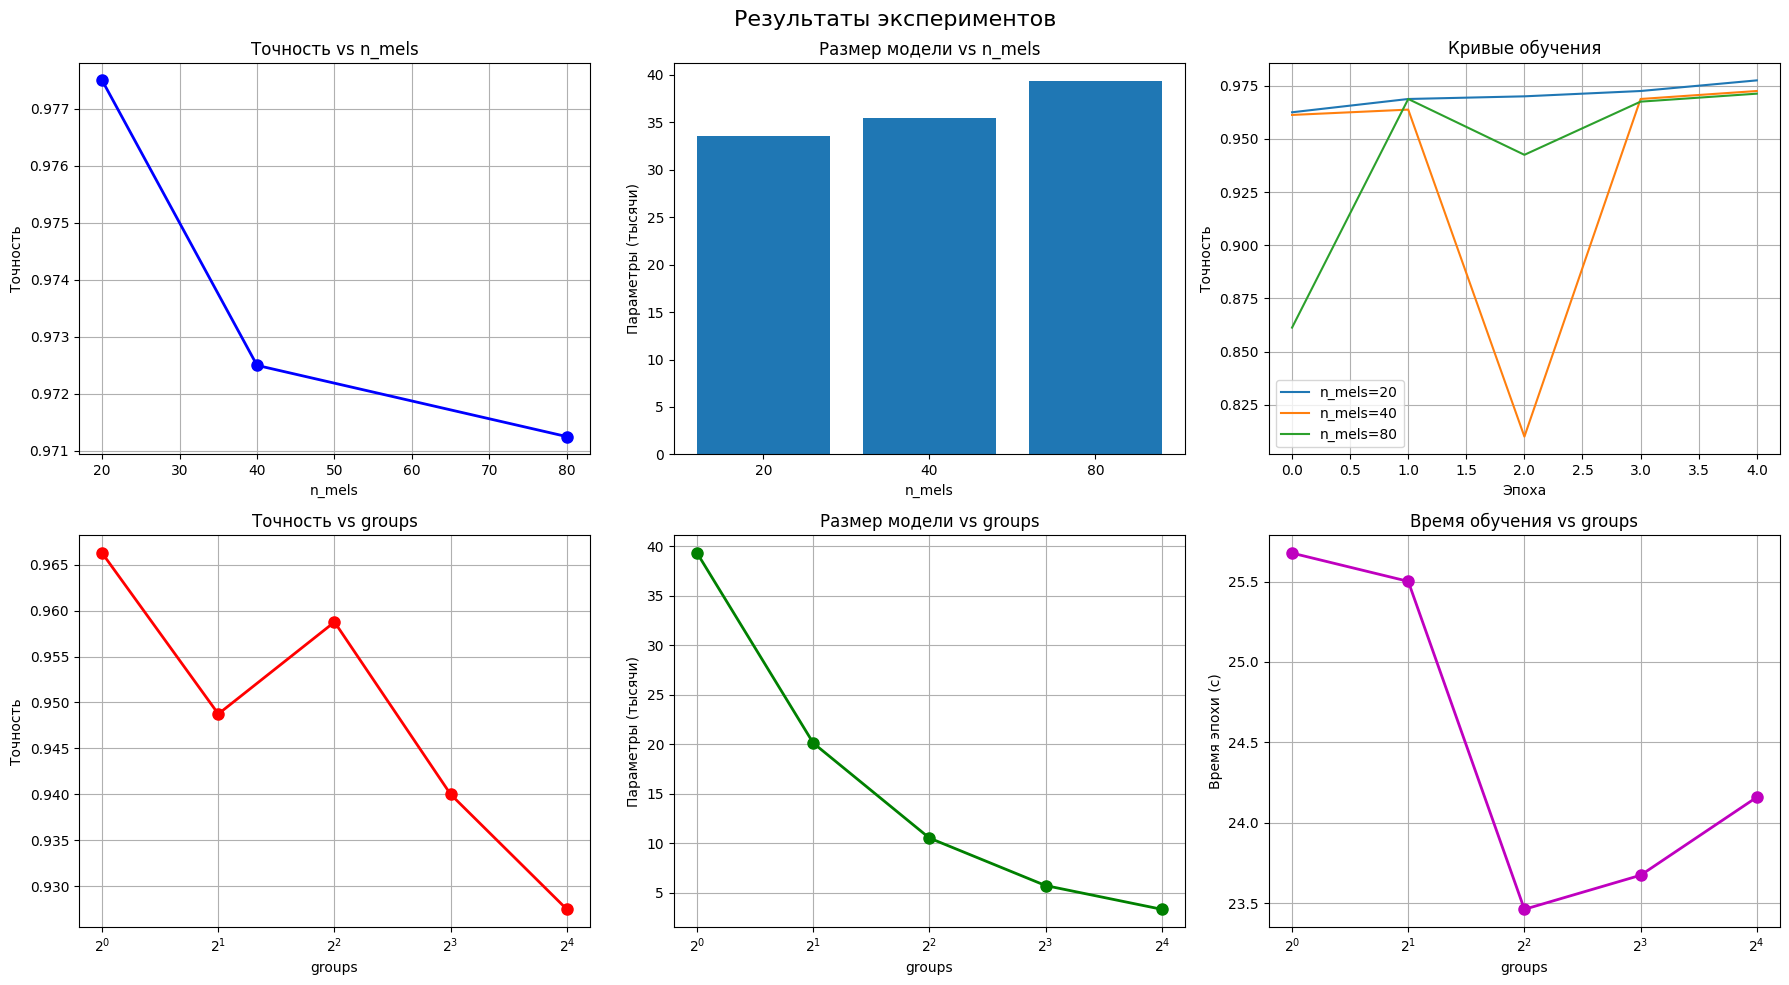

Графики сохранены в 'experiment_results.png'
Резы экспериментов

 n_mels
n_mels | Точность | Параметры | FLOPs
    20 | 0.9775 | 33.6K | 0.00G
    40 | 0.9725 | 35.5K | 0.00G
    80 | 0.9712 | 39.3K | 0.00G

 groups
groups | Точность | Параметры | FLOPs | Время/эп
     1 | 0.9663 | 39.3K | 0.00G | 25.68с
     2 | 0.9487 | 20.1K | 0.00G | 25.50с
     4 | 0.9587 | 10.5K | 0.00G | 23.46с
     8 | 0.9400 | 5.7K | 0.00G | 23.67с
    16 | 0.9275 | 3.3K | 0.00G | 24.16с

 Файлы для отчета:
   - comparison_plot.png (сравнение с torchaudio)
   - experiment_results.png (графики экспериментов)


In [42]:
# Запускаем эксперименты
print("Обучение CNN")
results = run_all_experiments()
plot_results(results)

# Сводная таблица
print("Резы экспериментов")

print("\n n_mels")
print("n_mels | Точность | Параметры | FLOPs")
for n in [20, 40, 80]:
    r = results[f'n_mels_{n}']
    print(f"{n:6d} | {r['final_val_acc']:.4f} | {r['params']/1000:.1f}K | {r['flops']/1e9:.2f}G")

print("\n groups")
print("groups | Точность | Параметры | FLOPs | Время/эп")

for g in [1, 2, 4, 8, 16]:
    r = results[f'groups_{g}']
    print(f"{g:6d} | {r['final_val_acc']:.4f} | {r['params']/1000:.1f}K | {r['flops']/1e9:.2f}G | {np.mean(r['epoch_times']):.2f}с")

print("\n Файлы для отчета:")
print("   - comparison_plot.png (сравнение с torchaudio)")
print("   - experiment_results.png (графики экспериментов)")

In [43]:
# Нормально посчитать FLOPs у меня так и не вышло, поэтому ниже подсчет вручную

# FLOPs_conv = 2 × kernel_size × in_channels × out_channels × output_length

def calculate_flops(n_mels=80, groups=1):
    """
    Ручной расчет FLOPs для модели SimpleCNN

    Args:
        n_mels: количество мел-фильтров (20, 40, 80)
        groups: параметр групповой свертки (1, 2, 4, 8, 16)

    Returns:
        dict: FLOPs в разных единицах измерения
    """
    # Константы
    kernel_size = 3

    # Размеры после каждого слоя
    n_frames = 98  # после Mel-spectrogram
    out_len1 = n_frames - kernel_size + 1  # 96
    out_len2 = out_len1 - kernel_size + 1  # 94
    out_len3 = out_len2 - kernel_size + 1  # 92

    # FLOPs для каждого слоя с учетом groups
    flops1 = 2 * kernel_size * n_mels * 32 * out_len1 // groups
    flops2 = 2 * kernel_size * 32 * 64 * out_len2 // groups
    flops3 = 2 * kernel_size * 64 * 128 * out_len3 // groups
    flops_fc = 2 * 128 * 2

    total_flops = flops1 + flops2 + flops3 + flops_fc

    return {
        'flops': total_flops,
        'flops_K': total_flops / 1e3,
        'flops_M': total_flops / 1e6,
        'flops_G': total_flops / 1e9,
        'формула': f'({flops1} + {flops2} + {flops3} + {flops_fc}) / {groups}'
    }

In [44]:
for n_mels in [20, 40, 80]:
    flops = calculate_flops(n_mels, groups=1)
    print(f"n_mels={n_mels}: {flops['flops_M']:.2f}M FLOPs")

n_mels=20: 6.05M FLOPs
n_mels=40: 6.41M FLOPs
n_mels=80: 7.15M FLOPs


In [45]:
for groups in [1, 2, 4, 8, 16]:
    flops = calculate_flops(n_mels=80, groups=groups)
    print(f"groups={groups}: {flops['flops_M']:.2f}M FLOPs")

groups=1: 7.15M FLOPs
groups=2: 3.58M FLOPs
groups=4: 1.79M FLOPs
groups=8: 0.89M FLOPs
groups=16: 0.45M FLOPs
